In [25]:
import icechunk
import xarray as xr
from srm import catalog
import duckdb
import geopandas as gpd
import rasterix
from rasterix.rasterize.rasterio import geometry_clip
import matplotlib.pyplot as plt
import seaborn as sns
from ibicus.debias import QuantileMapping
# import matplotlib.style as mplstyle
# mplstyle.use('fast')

In [26]:
catalog

Dataset Catalog (6 datasets)
--------------------------------------------------------------------------------
CESM-WACCM-Historical-icechunk | icechunk   | s3://carbonplan-srm/input/tensor/CESM2-WACCM-Historical/icechunk/icechunk
CESM-WACCM-Historical-virtual | icechunk   | s3://carbonplan-srm/input/tensor/CESM2-WACCM-Historical/icechunk/virtual_icechunk
CESM-WACCM-G6-1.5K-icechunk | icechunk   | s3://carbonplan-srm/input/tensor/CESM-WACCM-G6-1.5K/icechunk/icechunk
CESM-WACCM-G6-1.5K-virtual | icechunk   | s3://carbonplan-srm/input/tensor/CESM-WACCM-G6-1.5K/icechunk/virtual_icechunk
CESM2-WACCM-SSP245-icechunk | icechunk   | s3://carbonplan-srm/input/tensor/CESM2-WACCM-SSP245/icechunk/icechunk
ERA5                 | icechunk   | s3://carbonplan-srm/input/tensor/era5_rechunked_resampled.icechunk

# Get data

In [27]:
var_cesm = "TREFHT"
var_era5 = "2m_temperature"
unit_conv_cesm_to_era5 = 1

In [28]:
def fix_coords(ds: xr.Dataset):
    ds.coords["lon"] = (ds.coords["lon"] + 180) % 360 - 180
    ds = ds.sortby(ssp245.lon)
    return ds

In [29]:
ssp245_cat = catalog.get("CESM2-WACCM-SSP245-icechunk")

ssp245_storage = icechunk.s3_storage(
    bucket=ssp245_cat.bucket,
    prefix=ssp245_cat.prefix,
    from_env=True,
)
ssp245_repo = icechunk.Repository.open(ssp245_storage)
ssp245_session = ssp245_repo.readonly_session("main")
ssp245 = xr.open_zarr(ssp245_session.store, consolidated=False)
ssp245 = fix_coords(ssp245)
ssp245 = ssp245.proj.assign_crs(spatial_ref="epsg:4326")

In [30]:
g61pt5k_cat = catalog.get("CESM-WACCM-G6-1.5K-icechunk")

g61pt5k_storage = icechunk.s3_storage(
    bucket=g61pt5k_cat.bucket,
    prefix=g61pt5k_cat.prefix,
    from_env=True,
)
g61pt5k_repo = icechunk.Repository.open(g61pt5k_storage)
g61pt5k_session = g61pt5k_repo.readonly_session("main")
g61pt5k = xr.open_zarr(g61pt5k_session.store, consolidated=False)
g61pt5k = fix_coords(g61pt5k)
g61pt5k = g61pt5k.isel(ensemble_member=0)

In [31]:
model_historical_cat = catalog.get("CESM-WACCM-Historical-icechunk")

model_historical_storage = icechunk.s3_storage(
    bucket=model_historical_cat.bucket,
    prefix=model_historical_cat.prefix,
    from_env=True,
)
model_historical_repo = icechunk.Repository.open(model_historical_storage)
model_historical_session = model_historical_repo.readonly_session("main")
model_historical = xr.open_zarr(model_historical_session.store, consolidated=False)
model_historical = fix_coords(model_historical)

In [32]:
era5_cat = catalog.get("ERA5")
era5_storage = icechunk.s3_storage(
    bucket=era5_cat.bucket,
    prefix=era5_cat.prefix,
    from_env=True,
)
era5_repo = icechunk.Repository.open(era5_storage)
era5_session = era5_repo.readonly_session("main")
era5 = xr.open_zarr(era5_session.store).pipe(rasterix.assign_index)
era5 = era5.proj.assign_crs(spatial_ref="epsg:4326")

In [33]:
df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'South Africa'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

In [34]:
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_x, cape_town_y = (
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),
)

# Subset data to demo region (South Africa)

In [35]:
era5_south_africa = geometry_clip(
    era5, south_africa_geom[["geometry"]], xdim="longitude", ydim="latitude"
)

era5_south_africa_bounds = era5.sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min),  # Note: descending order for latitude
)

In [36]:
ssp245_south_africa_bounds = ssp245.sortby("lat", ascending=False).sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min),  # Note: descending order for latitude
)

ssp245_south_africa = geometry_clip(
    ssp245.sortby("lat", ascending=False),
    south_africa_geom[["geometry"]],
    xdim="lon",
    ydim="lat",
)

In [37]:
g61pt5k_south_africa_bounds = g61pt5k.sortby("lat", ascending=False).sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min),  # Note: descending order for latitude
)

g61pt5k_south_africa = geometry_clip(
    g61pt5k.sortby("lat", ascending=False),
    south_africa_geom[["geometry"]],
    xdim="lon",
    ydim="lat",
)

In [38]:
model_historical_south_africa_bounds = (
    model_historical.sortby("lat", ascending=False)
    .sel(
        lon=slice(lon_min, lon_max),
        lat=slice(lat_max, lat_min),  # Note: descending order for latitude
    )
    .load()
)

model_historical_south_africa = geometry_clip(
    model_historical.sortby("lat", ascending=False),
    south_africa_geom[["geometry"]],
    xdim="lon",
    ydim="lat",
).load()

### Look at raw input data in demo region

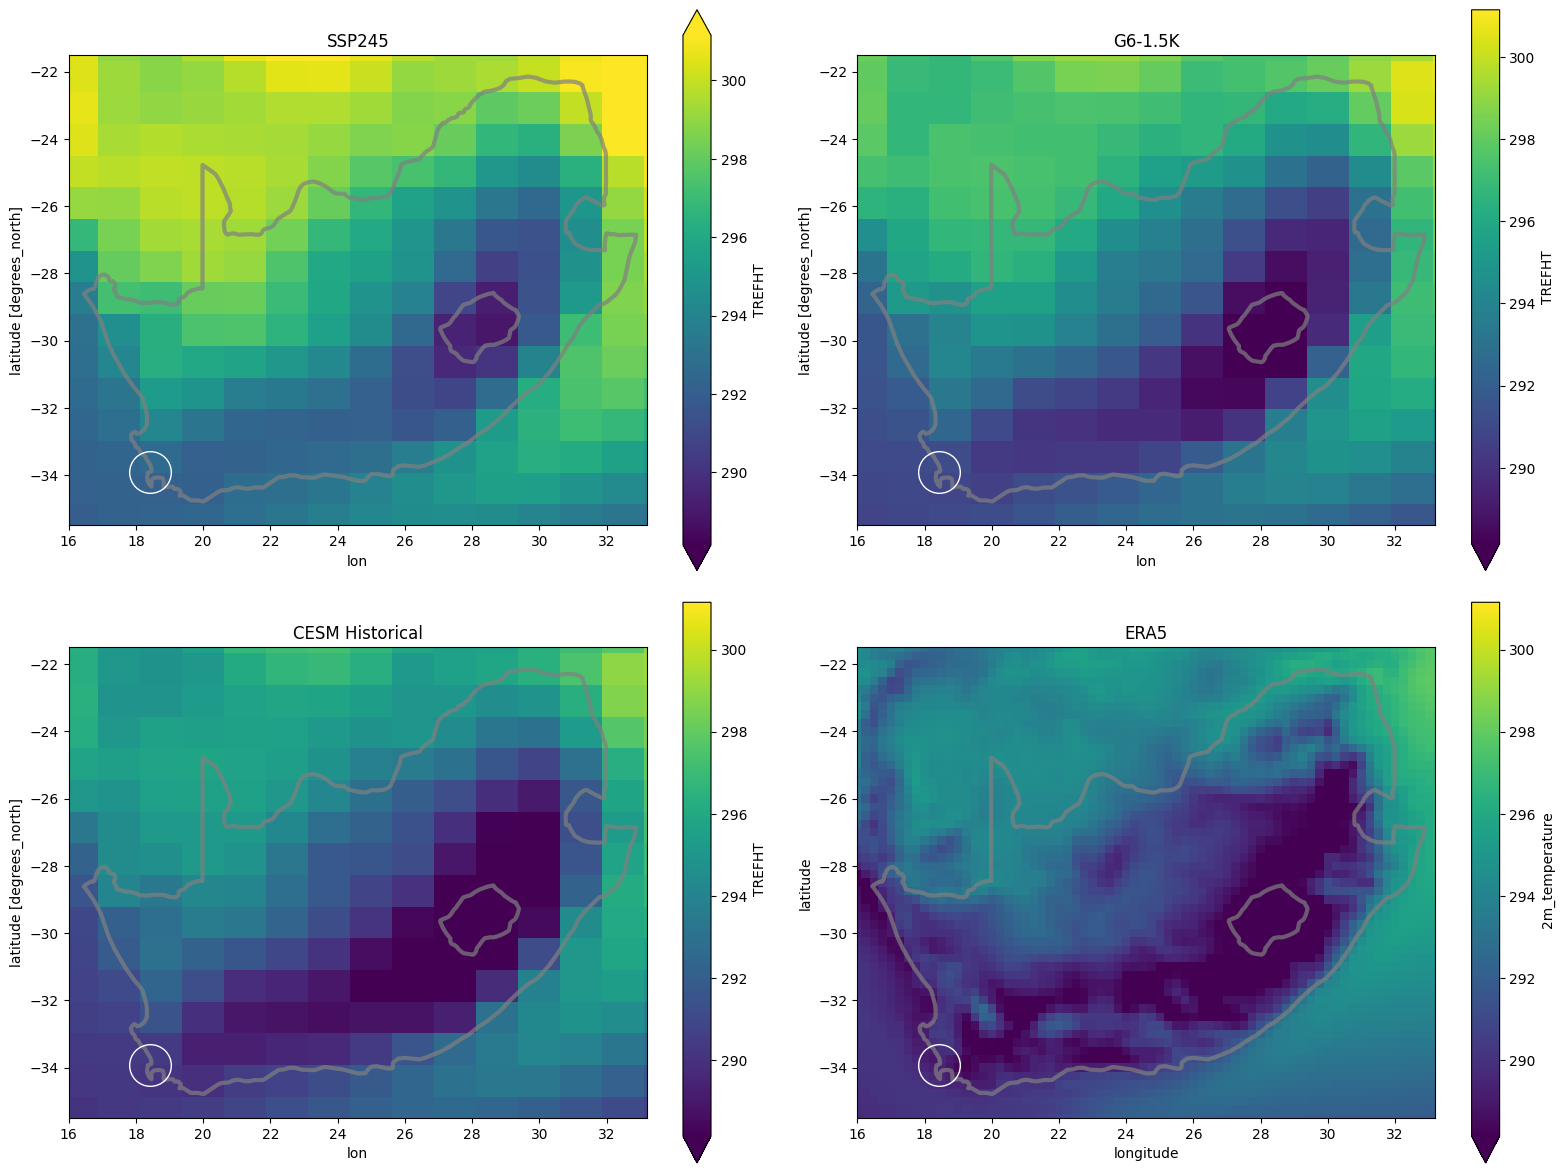

In [39]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
vmin = 15 + 273.15  # 0 #15+273.15
vmax = 28 + 273.15  # 5.5e-5 #30+273.15


def format_subplot(ax):
    south_africa_geom["geometry"].plot(
        ax=ax, facecolor="none", edgecolor="gray", linewidth=3, alpha=0.7
    )
    ax.set_xlim([16, 33.2])
    ax.set_ylim([-35.5, -21.5])
    ax.plot([cape_town_x], [cape_town_y], "ow", fillstyle="none", markersize=30)


ax = axes[0, 0]
(
    (ssp245_south_africa_bounds[var_cesm] * unit_conv_cesm_to_era5)
    .sel(time=ssp245_south_africa_bounds.time.dt.year >= 2090)
    .mean(dim="time")
).plot(ax=ax, add_colorbar=True, vmin=vmin, vmax=vmax)
format_subplot(ax)
ax.set_title("SSP245")

ax = axes[0, 1]
(g61pt5k_south_africa_bounds[var_cesm] * unit_conv_cesm_to_era5).sel(
    time=g61pt5k_south_africa_bounds.time.dt.year >= 2070
).mean(dim="time").plot(ax=ax, add_colorbar=True, vmin=vmin, vmax=vmax)
format_subplot(ax)
ax.set_title("G6-1.5K")

ax = axes[1, 1]
(era5_south_africa_bounds[var_era5].mean(dim="time")).plot(
    ax=ax, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("ERA5")

ax = axes[1, 0]
(
    (model_historical_south_africa_bounds[var_cesm] * unit_conv_cesm_to_era5).mean(
        dim="time"
    )
).plot(ax=ax, add_colorbar=True, vmin=vmin, vmax=vmax)
format_subplot(ax)
ax.set_title("CESM Historical")

plt.tight_layout()
plt.show()

# Step 1: Bias correct coarse model data

### Prep data

In [40]:
era5_south_africa_bounds_coarse = era5_south_africa_bounds.interp(
    longitude=ssp245_south_africa_bounds.lon,
    latitude=ssp245_south_africa_bounds.lat,
    method="linear",
)

In [41]:
era5_south_africa_bounds_coarse = era5_south_africa_bounds_coarse.where(
    era5_south_africa_bounds_coarse["time.year"] >= 1978, drop=True
)
model_historical_south_africa_bounds = model_historical_south_africa_bounds.where(
    model_historical_south_africa_bounds["time.year"] <= 2015, drop=True
)

In [42]:
tas_obs_xr = era5_south_africa_bounds_coarse["2m_temperature"]
tas_cm_hist_xr = model_historical_south_africa_bounds["TREFHT"]
tas_cm_g61pt5k_xr = g61pt5k_south_africa_bounds["TREFHT"]
tas_cm_ssp245_xr = ssp245_south_africa_bounds["TREFHT"]

tas_obs = tas_obs_xr.values
time_obs = tas_obs_xr["time"].values
tas_cm_hist = tas_cm_hist_xr.values
time_cm_hist = tas_cm_hist_xr["time"].values
tas_cm_g61pt5k = tas_cm_g61pt5k_xr.values
time_cm_g61pt5k = tas_cm_g61pt5k_xr["time"].values
tas_cm_ssp245 = tas_cm_ssp245_xr.values
time_cm_ssp245 = tas_cm_ssp245_xr["time"].values

### Initialize debiaser

In [43]:
debiaser = QuantileMapping.from_variable(variable="tas")

### Debias model output

In [44]:
tas_cm_hist_debiased = debiaser.apply(
    obs=tas_obs,
    cm_hist=tas_cm_hist,
    cm_future=tas_cm_hist,
    time_obs=time_obs,
    time_cm_hist=time_cm_hist,
)

g61pt5k_fut_debiased = debiaser.apply(
    obs=tas_obs,
    cm_hist=tas_cm_hist,
    cm_future=tas_cm_g61pt5k,
    time_obs=time_obs,
    time_cm_hist=time_cm_hist,
    time_cm_future=time_cm_g61pt5k,
)

ssp245_fut_debiased = debiaser.apply(
    obs=tas_obs,
    cm_hist=tas_cm_hist,
    cm_future=tas_cm_ssp245,
    time_obs=time_obs,
    time_cm_hist=time_cm_hist,
    time_cm_future=time_cm_ssp245,
)

100%|██████████| 620/620 [00:00<00:00, 626.45it/s]


### Process output to xarray and extract Cape Town time series

In [45]:
tas_cm_hist_debiased_xr = xr.DataArray(
    data=tas_cm_hist_debiased,
    coords={
        "lat": tas_cm_hist_xr["lat"],
        "lon": tas_cm_hist_xr["lon"],
        "time": tas_cm_hist_xr["time"],
    },
    dims=["time", "lat", "lon"],
)

g61pt5k_fut_debiased_xr = xr.DataArray(
    data=g61pt5k_fut_debiased,
    coords={
        "lat": tas_cm_g61pt5k_xr["lat"],
        "lon": tas_cm_g61pt5k_xr["lon"],
        "time": tas_cm_g61pt5k_xr["time"],
    },
    dims=["time", "lat", "lon"],
)


ssp245_fut_debiased_xr = xr.DataArray(
    data=ssp245_fut_debiased,
    coords={
        "lat": tas_cm_ssp245_xr["lat"],
        "lon": tas_cm_ssp245_xr["lon"],
        "time": tas_cm_ssp245_xr["time"],
    },
    dims=["time", "lat", "lon"],
)

In [46]:
tas_obs_xr_CT = tas_obs_xr.sel(lat=cape_town_y, lon=cape_town_x, method="nearest")
tas_cm_hist_xr_CT = tas_cm_hist_xr.sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
)
tas_cm_g61pt5k_xr_CT = tas_cm_g61pt5k_xr.sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
)

tas_cm_ssp245_xr_CT = tas_cm_ssp245_xr.sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
)

g61pt5k_fut_debiased_xr_CT = g61pt5k_fut_debiased_xr.sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
)

tas_cm_hist_debiased_xr_CT = tas_cm_hist_debiased_xr.sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
)

ssp245_fut_debiased_xr_CT = ssp245_fut_debiased_xr.sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
)

# Make figures of raw vs. debiased distributions at Cape Town

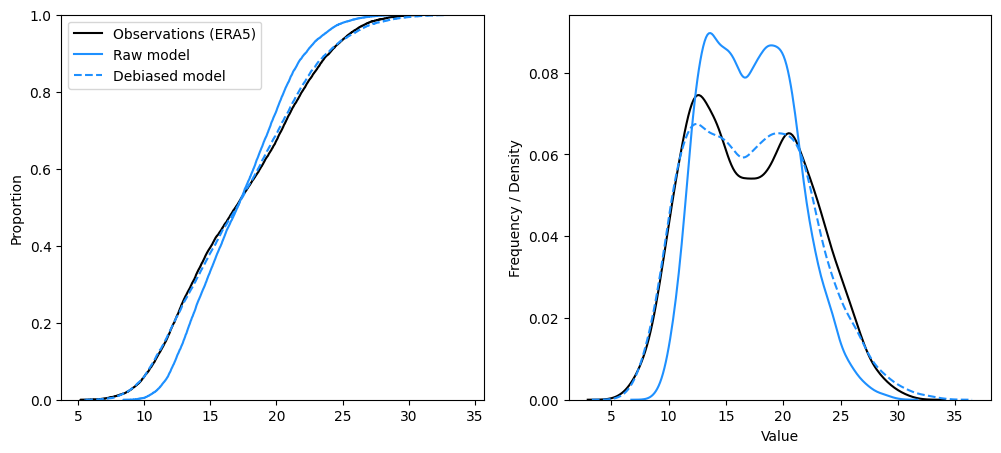

In [47]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.ecdfplot(tas_obs_xr_CT - 273.15, label="Observations (ERA5)", color="k")
sns.ecdfplot(tas_cm_hist_xr_CT - 273.15, label="Raw model", color="dodgerblue")
sns.ecdfplot(
    tas_cm_hist_debiased_xr_CT - 273.15,
    label="Debiased model",
    color="dodgerblue",
    linestyle="--",
)
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(tas_obs_xr_CT - 273.15, label="Observations (ERA5)", color="k")
sns.kdeplot(tas_cm_hist_xr_CT - 273.15, label="Raw model", color="dodgerblue")
sns.kdeplot(
    tas_cm_hist_debiased_xr_CT - 273.15,
    label="Debiased model",
    color="dodgerblue",
    linestyle="--",
)
plt.xlabel("Value")
plt.ylabel("Frequency / Density")
plt.show()

In [ ]:
xmax = 38
ymax = 0.10

plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
sns.kdeplot(
    tas_obs_xr_CT - 273.15,
    label="Observations (ERA5)",
    color="gray",
    linewidth=7,
    alpha=0.3,
)
sns.kdeplot(
    tas_cm_hist_xr_CT - 273.15,
    label="Modeled historical (raw)",
    color="black",
    linestyle="--",
)
sns.kdeplot(
    tas_cm_g61pt5k_xr_CT - 273.15,
    label="Modeled G6-1.5K",
    color="orange",
    linestyle="--",
)
sns.kdeplot(
    tas_cm_ssp245_xr_CT - 273.15, label="Modeled G6-1.5K", color="red", linestyle="--"
)
plt.title("Raw model output")
plt.ylim([0, ymax])
plt.xlim([4.5, xmax])

plt.subplot(2, 2, 2)

sns.kdeplot(
    tas_obs_xr_CT - 273.15,
    label="Observations (ERA5)",
    color="gray",
    linewidth=7,
    alpha=0.3,
)

sns.kdeplot(
    tas_cm_hist_debiased_xr_CT - 273.15,
    label="Modeled historical (debiased)",
    color="black",
    linestyle="-",
)

sns.kdeplot(
    g61pt5k_fut_debiased_xr_CT - 273.15,
    label="Modeled G6-1.5K (debiased)",
    color="orange",
    linestyle="-",
)
sns.kdeplot(
    ssp245_fut_debiased_xr_CT - 273.15,
    label="Modeled SSP245 (debiased)",
    color="red",
    linestyle="-",
)
plt.title("Debiased model output")
plt.legend(fontsize=6)
plt.ylim([0, ymax])
plt.xlim([4.5, xmax])

plt.subplot(2, 2, 3)
sns.ecdfplot(
    tas_obs_xr_CT - 273.15,
    label="Observations (ERA5)",
    color="gray",
    linewidth=7,
    alpha=0.3,
)
sns.ecdfplot(
    tas_cm_hist_xr_CT - 273.15,
    label="Modeled historical (raw)",
    color="black",
    linestyle="--",
)
sns.ecdfplot(
    g61pt5k_fut_debiased_xr_CT - 273.15,
    label="Modeled G6-1.5K",
    color="orange",
    linestyle="--",
)
sns.ecdfplot(
    ssp245_fut_debiased_xr_CT - 273.15,
    label="Modeled G6-1.5K",
    color="red",
    linestyle="--",
)
plt.title("Raw model output")

plt.subplot(2, 2, 4)

sns.ecdfplot(
    tas_obs_xr_CT - 273.15,
    label="Observations (ERA5)",
    color="gray",
    linewidth=7,
    alpha=0.3,
)

sns.ecdfplot(
    tas_cm_hist_debiased_xr_CT - 273.15,
    label="Modeled historical (debiased)",
    color="black",
    linestyle="-",
)

sns.ecdfplot(
    g61pt5k_fut_debiased_xr_CT - 273.15,
    label="Modeled G6-1.5K (debiased)",
    color="orange",
    linestyle="-",
)
sns.ecdfplot(
    ssp245_fut_debiased_xr_CT - 273.15,
    label="Modeled SSP245 (debiased)",
    color="red",
    linestyle="-",
)
plt.title("Debiased model output")
plt.legend(fontsize=6)

# Step 2: downscale data to finer spatial scale

### Calculate anomaly spatial pattern
Calculate a fine-resolution spatial anomaly pattern derived from the observations

In [ ]:
def calculate_error_map():
    era5_south_africa_bounds_coarse_reset = (
        era5_south_africa_bounds_coarse.reset_coords(
            ["longitude", "latitude"], drop=True
        )
    )

    era5_coarse_on_fine_grid = era5_south_africa_bounds_coarse_reset[var_era5].interp(
        lon=era5_south_africa_bounds["longitude"],
        lat=era5_south_africa_bounds["latitude"],
        method="linear",
    )
    error_map = era5_south_africa_bounds[var_era5].mean(
        dim="time"
    ) - era5_coarse_on_fine_grid.mean(dim="time")

    return error_map

In [ ]:
error_map = calculate_error_map()

### Downscale from coarse to fine scale
Spatially disaggregate from coarse-resolution to fine-resolution grid by bilinearly interpolating, then apply the fine-resolution spatial anomaly pattern derived from the observations

In [ ]:
def downscale_from_coarse(da, error_map=error_map, fine_grid=era5_south_africa_bounds):
    da_fine_grid = da.interp(
        lon=fine_grid["longitude"],
        lat=fine_grid["latitude"],
        method="linear",
    )

    return da_fine_grid + error_map

In [ ]:
model_historical_fine = downscale_from_coarse(
    model_historical_south_africa_bounds[var_cesm] * unit_conv_cesm_to_era5
)
model_historical_debiased_fine = downscale_from_coarse(
    tas_cm_hist_debiased_xr * unit_conv_cesm_to_era5
)

# Make maps of debiased and downscaled historical data

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 12))
vmin = 23 + 273.15
vmax = 37 + 273.15
cmap = plt.cm.coolwarm


def format_subplot(ax):
    south_africa_geom["geometry"].plot(
        ax=ax, facecolor="none", edgecolor="gray", linewidth=3, alpha=0.7
    )
    ax.set_xlim([16, 33.2])
    ax.set_ylim([-35.5, -21.5])
    ax.plot([cape_town_x], [cape_town_y], "ow", fillstyle="none", markersize=30)


ax = axes[0, 0]
model_raw = model_historical_south_africa_bounds[var_cesm] * unit_conv_cesm_to_era5
(model_raw.max(dim="time")).plot(
    ax=ax, cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("Model historical (raw)")

ax = axes[1, 0]
(model_historical_fine.max(dim="time")).plot(
    ax=ax, cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("Model historical (downscaled)")

ax = axes[0, 1]
(tas_cm_hist_debiased_xr * unit_conv_cesm_to_era5).max(dim="time").plot(
    ax=ax, cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("Model historical (debiased)")

ax = axes[1, 1]
(model_historical_debiased_fine.max(dim="time")).plot(
    ax=ax, cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("Model historical (debiased + downscaled)")

ax = axes[0, 2]
(era5_south_africa_bounds_coarse[var_era5].max(dim="time")).plot(
    ax=ax, cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("ERA5 (coarsened)")

ax = axes[1, 2]
(era5_south_africa_bounds[var_era5].max(dim="time")).plot(
    ax=ax, cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("ERA5")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 12))
vmin = 12 + 273.15
vmax = 23 + 273.15
cmap = plt.cm.coolwarm


def format_subplot(ax):
    south_africa_geom["geometry"].plot(
        ax=ax, facecolor="none", edgecolor="gray", linewidth=3, alpha=0.7
    )
    ax.set_xlim([16, 33.2])
    ax.set_ylim([-35.5, -21.5])
    ax.plot([cape_town_x], [cape_town_y], "ow", fillstyle="none", markersize=30)


ax = axes[0, 0]
model_raw = model_historical_south_africa_bounds[var_cesm] * unit_conv_cesm_to_era5
(model_raw.mean(dim="time")).plot(
    ax=ax, cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("Model historical (raw)")

ax = axes[1, 0]
(model_historical_fine.mean(dim="time")).plot(
    ax=ax, cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("Model historical (downscaled)")

ax = axes[0, 1]
(tas_cm_hist_debiased_xr * unit_conv_cesm_to_era5).mean(dim="time").plot(
    ax=ax, cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("Model historical (debiased)")

ax = axes[1, 1]
(model_historical_debiased_fine.mean(dim="time")).plot(
    ax=ax, cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("Model historical (debiased + downscaled)")

ax = axes[0, 2]
(era5_south_africa_bounds_coarse[var_era5].mean(dim="time")).plot(
    ax=ax, cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("ERA5 (coarsened)")

ax = axes[1, 2]
(era5_south_africa_bounds[var_era5].mean(dim="time")).plot(
    ax=ax, cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)
format_subplot(ax)
ax.set_title("ERA5")

plt.tight_layout()
plt.show()